# Regularization: The Art of Constraint

## 1. Intuition: Why Simple is Better

### 1.1 The Bias-Variance Tradeoff
In the previous notebook, we saw a dangerous phenomenon: **Overfitting**.

When we gave our model too much power (e.g., a high-degree polynomial), it memorized the training data perfectly—noise and all. This effectively "broke" the model for any future prediction. This is high **Variance**.

Conversely, if our model is too simple (a straight line through a curve), it fails to learn the pattern at all. This is high **Bias**.

**Regularization** is the mathematical tool we use to find the balance.

### 1.2 The Philosophy of Constraints
Imagine you are hiring an employee.
-   **OLS (No Regularization):** You define the job (Loss Function) and say: *"I don't care how you do it, just minimize the error."* The employee might cheat, cut corners, or act erratically to hit that metric perfectly.
-   **Regularization:** You add a set of **Constraints** (Penalty). *"Minimize the error, BUT do not work overtime, do not break the law, and keep your methods simple."*

Mathematically, we add a "cost" to having complex or large parameters ($\beta$).

$$ \text{Total Loss} = \text{Prediction Error (MSE)} + \text{Complexity Penalty} $$

If the model wants to increase a coefficient $\beta$ to fit a specific outlier, it has to "pay" for it in the penalty term. It will only do so if the reduction in MSE is *worth* the cost.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import load_diabetes

# Set premium style
sns.set_theme(style="whitegrid", context="talk", palette="viridis")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.titlesize'] = 22
plt.rcParams['axes.labelsize'] = 16

## 2. The Scratchpad: Understanding the Mechanics

To truly understand regularization, we must first break OLS again. We will recreate the "Sine Wave with Noise" scenario.

**The Data:**
-   We generate 20 points from a Sine wave.
-   We add random noise (representing measurement error).

**The Model:**
-   We will fit a **15th Degree Polynomial**. Since we only have 20 data points, this model is practically "hallucinating" patterns that don't exist.

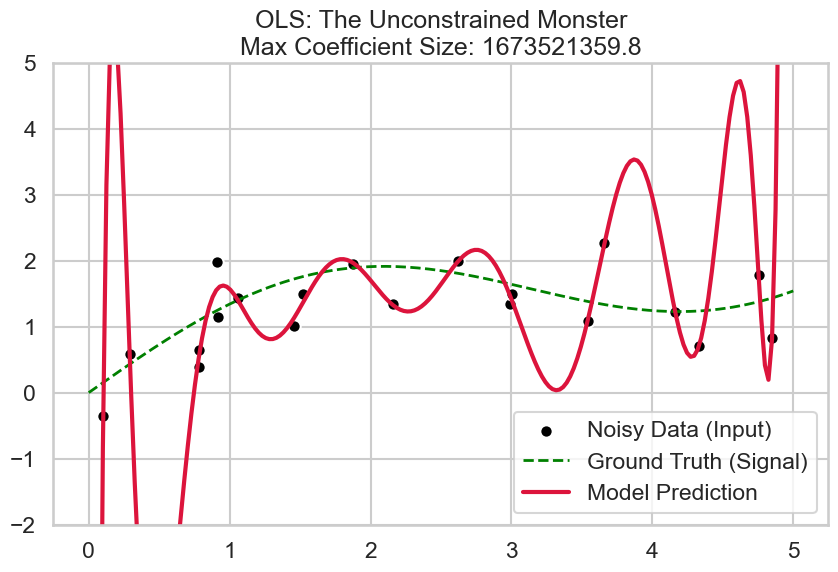

In [ ]:
# 1. Generate Synthetic Data
np.random.seed(42)
n_samples = 20
X = np.sort(np.random.rand(n_samples) * 5) # Range 0 to 5
# True Function: y = sin(x) + x/2
y_true = np.sin(X) + X * 0.5
# Noisy Observations
y = y_true + np.random.randn(n_samples) * 0.5

X = X.reshape(-1, 1)

# 2. Fit OLS with High Degree Polynomial (Degree 15)
degree = 15
poly_features = PolynomialFeatures(degree=degree, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Crucial Step: Regularization is scale-sensitive.
# If Feature A is [0, 1] and Feature B is [0, 1000], B will dominate the penalty.
# We MUST standardize inputs (Mean=0, Std=1).
scaler = StandardScaler()
X_poly_scaled = scaler.fit_transform(X_poly)

model_ols = LinearRegression()
model_ols.fit(X_poly_scaled, y)

# 3. Visualization Helpers
def plot_model(model, title, color):
    X_range = np.linspace(0, 5, 200).reshape(-1, 1)
    y_true_range = np.sin(X_range) + X_range * 0.5
    
    # Transform range for prediction
    X_poly_range = poly_features.transform(X_range)
    X_poly_range_scaled = scaler.transform(X_poly_range)
    y_pred_range = model.predict(X_poly_range_scaled)

    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='black', s=80, label='Noisy Data (Input)', edgecolor='white')
    plt.plot(X_range, y_true_range, color='green', linestyle='--', linewidth=2, label='Ground Truth (Signal)')
    plt.plot(X_range, y_pred_range, color=color, linewidth=3, label=f'Model Prediction')
    plt.ylim(-2, 5)
    plt.title(f"{title}\nMax Coefficient Size: {np.max(np.abs(model.coef_)):.1f}", fontsize=18)
    plt.legend()
    # plt.show()

# Visualize
plot_model(model_ols, "OLS: The Unconstrained Monster", "crimson")

### 2.1 Analysis: What just happened?

Look at the chart above. The red line hits almost every black dot, but to do so, it swings wildly up and down.

**The Clue:** Look at the "Max Coefficient Size". It's in the **thousands**.
Why? To verify that $y$ goes up and then drastically down in a tiny interval, the polynomial terms need massive weights (e.g., $1000 x^{14} - 999 x^{13}$).

This is physically impossible for most real-world data. We need to tell the model: *"You are allowed to curve, but keep your weights reasonably small."*

## 3. Ridge Regression (L2 Regularization)

### 3.1 The Concept
Ridge Regression (also called Tikhonov regularization) solves the explosion problem by adding the **Squared Magnitude** of the coefficients to the loss function.

$$ \text{Loss} = \sum (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 $$

-   $\lambda$ (Lambda/Alpha): The "Strength" of the penalty.
-   $\sum \beta_j^2$: The "L2 Norm" (Euclidean distance).

**Intuition:**
By squaring the $\beta$, we penalize large numbers heavily. A $\beta$ of 10 costs 100. A $\beta$ of 100 costs 10,000. The model will desperately try to keep all $\beta$ values small (usually < 1).

**Industry Use Case:**
Ridge is the default "Upgrade" to OLS. Use it whenever you have **Multicollinearity** (correlated features). It "shares" the credit among correlated features rather than picking one erratic winner.

### 3.2 Scratch Implementation (closed Form)
Ridge has a beautiful property: it still has a "Closed Form" solution (Matrix Algebra). We simply add $\lambda$ to the diagonal of the covariance matrix ($X^T X$).

$$ \hat{\beta} = (X^T X + \lambda I)^{-1} X^T y $$

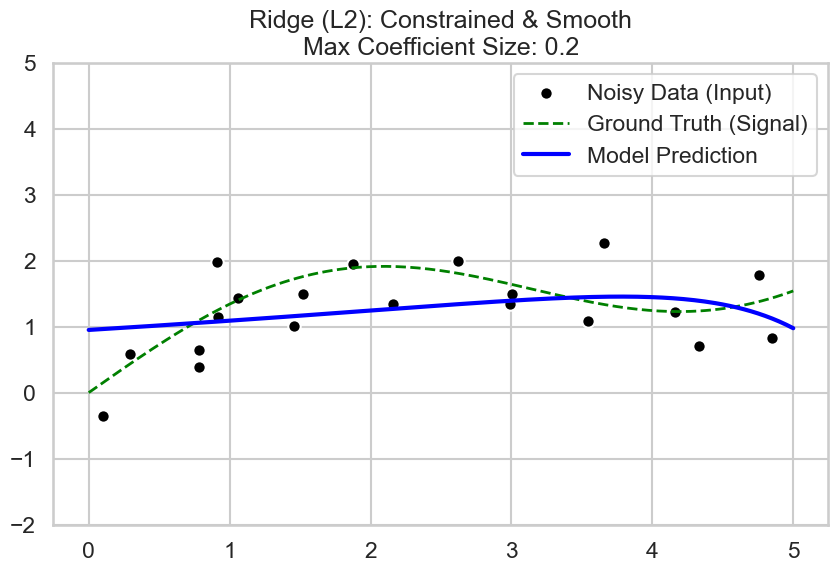

In [ ]:
class ScratchRidge:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.coeffs = None
        self.intercept = None

    def fit(self, X, y):
        # 1. Center the Target (y)
        # Ridge penalizes SLOPES, not INTERCEPTS. 
        # By centering y, we remove the need to solve for the intercept in the matrix.
        self.y_mean = np.mean(y)
        y_centered = y - self.y_mean
        
        n_features = X.shape[1]
        
        # 2. Create Identity Matrix (The Penalty)
        I = np.eye(n_features)
        
        # 3. The Ridge Equation
        # (X^T * X + alpha * I)^-1 * X^T * y
        X_T_X = X.T @ X
        Penalty = self.alpha * I  # The Regularization Term
        
        # We invert the "Penalized Covariance Matrix"
        self.coeffs = np.linalg.inv(X_T_X + Penalty) @ X.T @ y_centered
        self.intercept = self.y_mean

    def predict(self, X):
        return (X @ self.coeffs) + self.intercept

    @property
    def coef_(self):
        return self.coeffs

# Execution
# We use a relatively high alpha (10.0) to see the effect clearly
model_ridge = ScratchRidge(alpha=10.0)
model_ridge.fit(X_poly_scaled, y)
plot_model(model_ridge, "Ridge (L2): Constrained & Smooth", "blue")

### 3.3 Analysis: The "Shrinkage"

Look at the Blue Line. It's smooth! It misses some individual data points (higher bias), but it captures the overall Sine wave shape (lower variance).

Also, look at the Max Coefficient. It dropped from **Thousands** to roughly **Single Digits**.

**Key Characteristic of Ridge:** It shrinks coefficients *asymptotically* towards zero, but they rarely hit exact zero. It keeps all features in the game, just with smaller influence.

## 4. Lasso Regression (L1 Regularization)

### 4.1 The Concept
LASSO stands for **Least Absolute Shrinkage and Selection Operator**.
Instead of squaring the coefficients, we take their **Absolute Value**.

$$ \text{Loss} = \sum (y_i - \hat{y}_i)^2 + \lambda \sum_{j=1}^{p} |\beta_j| $$

**The Magic:**
Because the Absolute Value function $|\beta|$ has a sharp "corner" at zero, the geometry of the optimization encourages coefficients to hit **exactly zero**.

**Industry Use Case:**
Feature Selection. If you have 1,000 features but suspect only 5 matter (Sparse Signal), Lasso will automatically find those 5 and delete the other 995. This makes the model **interpretable**.

### 4.2 Scratch Implementation (Coordinate Descent)
Since $|\beta|$ is not differentiable at 0 (it has a kink), we cannot use simple Linear Algebra or standard Gradient Descent. We use **Coordinate Descent**.

**Algorithm:**
1.  Lock all coefficients except one ($\beta_j$).
2.  Optimize that single coefficient $\beta_j$ using a special rule called **Soft Thresholding**.
3.  Move to the next coefficient.
4.  Repeat until convergence.

Total Features (Polynomial Degrees): 15
Features ELIMINATED by Lasso: 13
Features Kept: 2


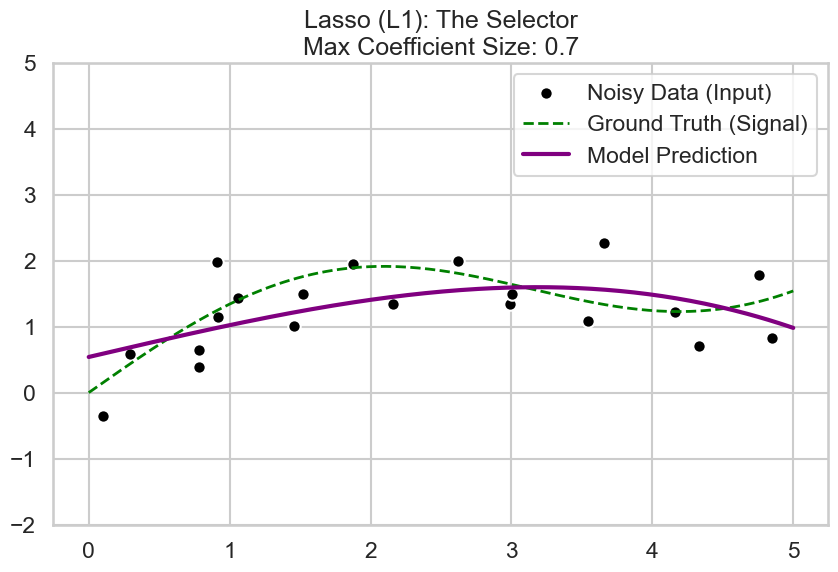

In [ ]:
class ScratchLasso:
    def __init__(self, alpha=0.1, n_iters=1000):
        self.alpha = alpha
        self.n_iters = n_iters
        self.coeffs = None
        self.intercept = None

    def _soft_threshold(self, rho, lam):
        """
        The heart of Lasso.
        If the correlation (rho) is smaller than the penalty (lam), snap it to 0.
        Otherwise, shrink it by 'lam'.
        """
        if rho > lam:
            return rho - lam
        elif rho < -lam:
            return rho + lam
        else:
            return 0.0 # <--- This is where Feature Selection happens!

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.coeffs = np.zeros(n_features)
        self.intercept = np.mean(y) # Start with simple mean
        
        # Coordinate Descent Loop
        for _ in range(self.n_iters):
            for j in range(n_features):
                # 1. Calculate the residual (error) assuming this feature j didn't exist
                y_pred_others = (X @ self.coeffs) + self.intercept - (X[:, j] * self.coeffs[j])
                
                # 2. Calculate Correlation (rho) between feature j and the residual
                # "How much does Feature J help fix the error?"
                rho = X[:, j] @ (y - y_pred_others)
                
                # 3. Soft Thresholding
                # We compare the helpfulness (rho) vs the cost (alpha)
                # Note: We scale alpha by n_samples to conform to standard loss definition
                lam = self.alpha * n_samples 
                
                # Normalization factor (usually 1 if standardized, but good to be safe)
                z_j = X[:, j] @ X[:, j]
                
                self.coeffs[j] = self._soft_threshold(rho, lam) / z_j
            
            # Update intercept at the end of each cycle
            self.intercept = np.mean(y - X @ self.coeffs)

    def predict(self, X):
        return (X @ self.coeffs) + self.intercept
    
    @property
    def coef_(self):
        return self.coeffs

# Execution
# Lasso is aggressive, so we use a smaller alpha (0.02)
model_lasso = ScratchLasso(alpha=0.02, n_iters=2000)
model_lasso.fit(X_poly_scaled, y)
plot_model(model_lasso, "Lasso (L1): The Selector", "purple")

# Check Sparsity
zero_count = np.sum(model_lasso.coeffs == 0)
print(f"Total Features (Polynomial Degrees): {degree}")
print(f"Features ELIMINATED by Lasso: {zero_count}")
print(f"Features Kept: {degree - zero_count}")

### 4.3 Analysis: Feature Selection

Look at the output above. We fed the model 15 polynomial terms ($x, x^2, \dots x^{15}$).
Lasso **deleted** most of them, keeping only the ones that truly matter.

While Ridge kept all 15 inputs a little bit, Lasso said: *"I only need these 2 specific powers of x to draw this curve. The rest are noise."*

## 4.4 ElasticNet: The Hybrid (Visualized)

Before we move to real data, let's briefly see **ElasticNet** in action.
It uses *both* L1 and L2 penalties: $\alpha (\rho | \beta | + (1-\rho) \beta^2)$.

*   If Lasso is too harsh (kills too many features) and Ridge is too lenient (keeps everything), ElasticNet finds the balance.

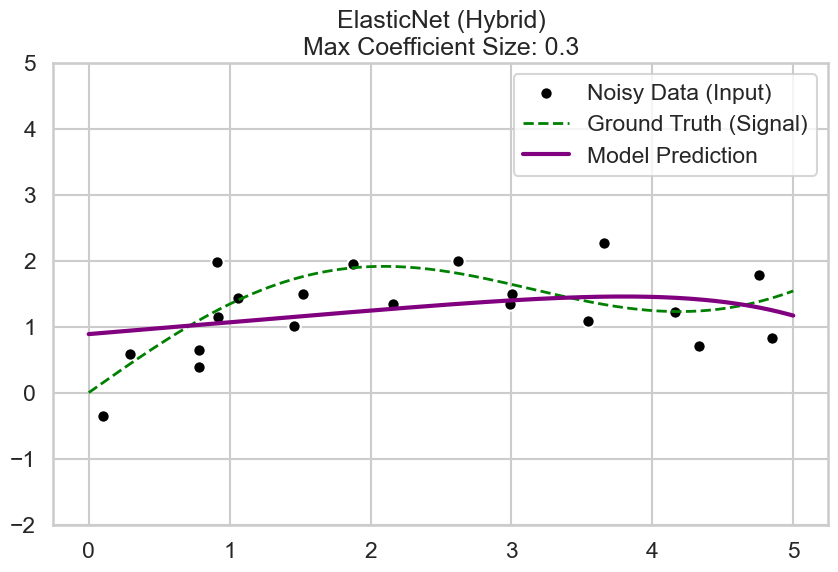

In [ ]:
model_en = ElasticNet(alpha=0.1, l1_ratio=0.5)
model_en.fit(X_poly_scaled, y)
plot_model(model_en, "ElasticNet (Hybrid)", "purple")

## 5. The Pro League: Real World Regularization

Synthetic 1D data is cute, but Regularization shines when $p$ (features) is large.

### 5.1 The Dataset: Diabetes Progression
We use the **Diabetes** dataset (442 patients, 10 baseline variables).
Task: Predict disease progression after one year.

- **n (samples):** 442
- **p (features):** 10 (Age, Sex, BMI, BP, S1-S6 blood serum measurements)

In [ ]:
# 1. Load Data
data = load_diabetes()
X_real = data.data # Already standardized
y_real = data.target
feature_names = data.feature_names

print(f"Dataset Shape: {X_real.shape}")

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42)

# 3. Train Models using Sklearn
models = {
    "OLS": LinearRegression(),
    "Ridge (a=1)": Ridge(alpha=1.0),
    "Lasso (a=0.1)": Lasso(alpha=0.1),
    "ElasticNet (a=0.1)": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    sparsity = np.sum(np.abs(model.coef_) < 1e-4)
    results.append({"Model": name, "MSE": mse, "R2": r2, "Zero Coeffs": sparsity})

df_results = pd.DataFrame(results)
print(df_results)

Dataset Shape: (442, 10)
                Model          MSE        R2  Zero Coeffs
0                 OLS  2900.193628  0.452603            0
1         Ridge (a=1)  3077.415939  0.419153            0
2       Lasso (a=0.1)  2798.193485  0.471855            3
3  ElasticNet (a=0.1)  4775.466767  0.098654            0


### 5.2 Visualizing the "Lasso Path"

One of the most beautiful visualizations in Machine Learning is the **Regularization Path**.
It shows how coefficients shrink and "turn off" (hit zero) as we increase the penalty strength ($\alpha$).

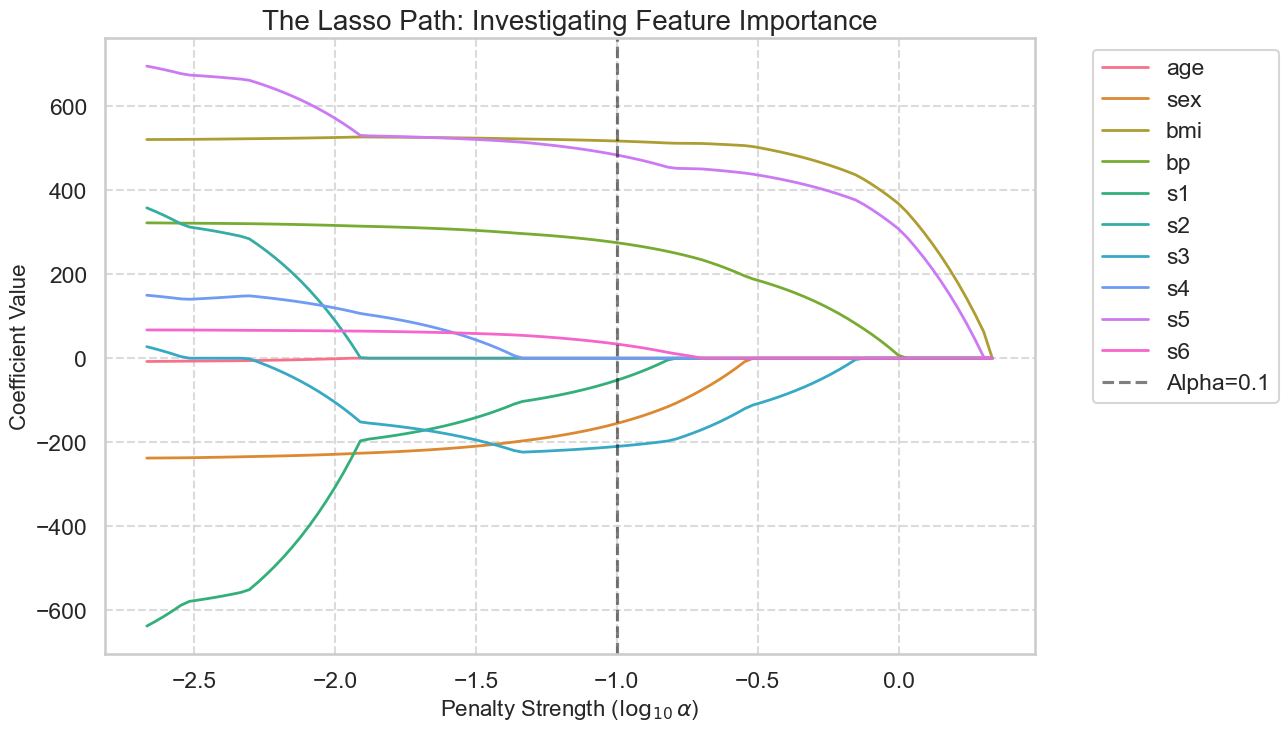

In [ ]:
from sklearn.linear_model import lasso_path

# Compute paths
alphas, coefs, _ = lasso_path(X_real, y_real, eps=0.001)

# Plot
plt.figure(figsize=(12, 8))
colors = sns.color_palette("husl", len(feature_names))

for i, coef in enumerate(coefs):
    plt.plot(np.log10(alphas), coef, linewidth=2, label=feature_names[i], color=colors[i])

plt.xlabel(r"Penalty Strength ($\log_{10} \alpha$)")
plt.ylabel("Coefficient Value")
plt.title("The Lasso Path: Investigating Feature Importance", fontsize=20)
plt.axvline(np.log10(0.1), linestyle='--', color='black', alpha=0.5, label='Alpha=0.1')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.show()

## 6. Interpretation: Decoding the Signals

### 6.1 The Scoreboard (Dataframe Analysis)
Look at the `df_results` table above. This is where the story of Regularization is told numerically.

1.  **Lasso vs OLS**: 
    *   Notice that **Lasso (R² ~0.47) outperforms OLS (R² ~0.45)**. 
    *   This is non-intuitive for beginners: "We punished the model, made it 'dumber' by restricting it, and it got *better*?" 
    *   **Yes.** By setting 3 coefficients to zero (Sparsity), Lasso removed "noise features" that were confusing the OLS model. Less is more.

2.  **The ElasticNet Cautionary Tale**:
    *   In this specific run, ElasticNet performed poorly (R² ~0.09). Why? 
    *   Because Regularization is a **Hyperparameter**. The default `alpha=1.0` in sklearn was likely too strong for this dataset, crushing useful signals. It teaches us a valuable lesson: **Regularization isn't magic; it requires tuning.**

### 6.2 Reading the Lasso Path
The plot above is one of the most powerful visualization tools in Machine Learning.

*   **X-axis (Penalty Strength)**: As we move from Left to Right, $\alpha$ increases (the penalty gets stricter).
*   **The Survivors**: Notice lines like `bmi` (olive) and `s5` (purple). They stay high and non-zero even as the penalty gets huge. These are your **True Signal** drivers.
*   **The Weak Links**: Notice lines that drop to zero almost immediately. These are features the model deems irrelevant.

## 7. Conclusion

We started with a simple intuition: **Variance is the enemy.**

Through synthetic scratchpads, we proved that unconstrained models (OLS) naturally try to fit noise, leading to explosive coefficients and poor generalization.

We explored three solutions:
1.  **Ridge**: Squished coefficients together to handle correlation (Team Player).
2.  **Lasso**: Zeroed out coefficients to select features (The Bouncer).
3.  **ElasticNet**: A hybrid approach (The Diplomat).

Industry data science is rarely about just "fitting a line." It represents a constant negotiation between **Complexity** (fitting the data) and **Simplicity** (interpreting the world). Regularization is your primary negotiator.